# Combinatorics (Permutations and Combinations)

## Contents
1. [Fundamental Principles of Counting](#1.-Fundamental-Principles-of-Counting)
2. [Factorials](#2.-Factorials)
3. [Permutations](#3.-Permutations)
4. [Permutations with Repetition and Identical Objects](#4.-Permutations-with-Repetition-and-Identical-Objects)
5. [Restricted Arrangements](#5.-Restricted-Arrangements)
6. [Circular Permutations](#6.-Circular-Permutations)
7. [Combinations](#7.-Combinations)
8. [Restricted Selections (Committees, At Least / At Most)](#8.-Restricted-Selections-(Committees,-At-Least-/-At-Most))
9. [Selections from Identical Objects and Number of Divisors](#9.-Selections-from-Identical-Objects-and-Number-of-Divisors)
10. [Distributions: Stars and Bars](#10.-Distributions:-Stars-and-Bars)
11. [Dividing into Groups](#11.-Dividing-into-Groups)
12. [Counting in Geometry and Grids](#12.-Counting-in-Geometry-and-Grids)
13. [Inclusion–Exclusion and Derangements](#13.-Inclusion–Exclusion-and-Derangements)
14. [Pigeonhole Principle](#14.-Pigeonhole-Principle)
15. [Rank of a Word in the Dictionary](#15.-Rank-of-a-Word-in-the-Dictionary)
16. [Common Mistakes](#16.-Common-Mistakes)
17. [Formula Sheet](#17.-Formula-Sheet)
18. [Practice Problems (with Answers)](#18.-Practice-Problems-(with-Answers))

Related notebook: `binomial_theorem.ipynb` (binomial coefficients and Pascal's triangle). The code cells **check formulas by brute-force enumeration** with `itertools`, so you can see that each formula really counts what it claims to.

In [1]:
import math
from math import comb, perm, factorial
from itertools import permutations, combinations, product
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

def count(iterable):
    """Count items produced by an iterator (brute force)."""
    return sum(1 for _ in iterable)

def multiset_perms(word):
    """Number of distinct arrangements of a word with repeated letters."""
    total = factorial(len(word))
    for k in Counter(word).values():
        total //= factorial(k)
    return total

print("Ready.")

Ready.


## 1. Fundamental Principles of Counting

### Multiplication principle (AND)
If a task is done in **stages**, with $m$ ways for the first stage and $n$ ways for the second (whatever happened in the first), the whole task can be done in $m \times n$ ways.

### Addition principle (OR)
If a task can be done in **one of several mutually exclusive ways** — $m$ ways of one kind or $n$ ways of another — there are $m + n$ ways.

**Rule of thumb:** "and" → multiply, "or" → add.

**Examples**
- 3 shirts and 4 trousers → $3 \times 4 = 12$ outfits.
- Travel by one of 5 trains or one of 3 buses → $5 + 3 = 8$ ways.
- Car number plates with 2 letters then 3 digits:
  - repetition allowed: $26^2 \times 10^3 = 676{,}000$
  - no repetition: $26 \times 25 \times 10 \times 9 \times 8 = 468{,}000$
- 5 roads from A to B and 4 from B to C: A → C via B in $5 \times 4 = 20$ ways. Round trip A → C → A **without reusing any road**: $5 \times 4 \times 3 \times 4 = 240$.

### Filling slots
Draw one slot per position, fill the **most restricted slot first**, then multiply.

**Example.** 4-digit numbers with no repeated digits: first digit $\neq 0$ → $9$ choices; then $9, 8, 7$ → $9 \times 9 \times 8 \times 7 = 4536$.

In [2]:
print("Outfits:", count(product(range(3), range(4))))
print("4-digit numbers, distinct digits:", count(p for p in permutations("0123456789", 4) if p[0] != "0"), "| formula:", 9*9*8*7)
print("Round trip, no road reused:", count((r1, r2, r3, r4) for r1 in range(5) for r2 in range(4)
                                           for r3 in range(4) for r4 in range(5) if r3 != r2 and r4 != r1))

Outfits: 12
4-digit numbers, distinct digits: 4536 | formula: 4536
Round trip, no road reused: 240


## 2. Factorials

$$n! = n(n - 1)(n - 2)\cdots 2 \cdot 1, \qquad 0! = 1, \qquad n! = n \cdot (n - 1)!$$

$0! = 1$ because there is exactly one way to arrange nothing (and it makes the formulas work).

| $n$ | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 10 |
|-----|---|---|---|---|---|---|---|---|---|----|
| $n!$ | 1 | 1 | 2 | 6 | 24 | 120 | 720 | 5040 | 40320 | 3628800 |

### Simplifying
$\dfrac{10!}{8!} = 10 \times 9 = 90$, $\quad\dfrac{(n + 1)!}{(n - 1)!} = (n + 1)n$.

### Power of a prime $p$ in $n!$ (Legendre's formula)
$$\left\lfloor\frac{n}{p}\right\rfloor + \left\lfloor\frac{n}{p^2}\right\rfloor + \left\lfloor\frac{n}{p^3}\right\rfloor + \dots$$
- Power of 2 in $10!$: $5 + 2 + 1 = 8$.
- **Trailing zeros** of $n!$ = power of 5 (there are always more 2s): $100!$ has $20 + 4 = 24$ trailing zeros.

$n!$ grows **faster than any exponential** $a^n$ (see the plot).

10!/8! = 90
power of 2 in 10!: 8 | check: 8
trailing zeros of 100!: 24 | check: 24


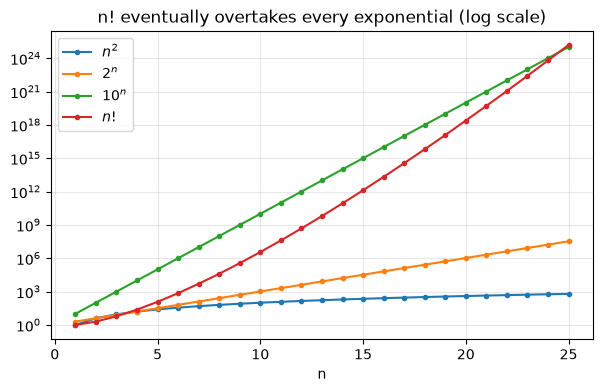

In [3]:
def legendre(n, p):
    e, q = 0, p
    while q <= n:
        e += n // q
        q *= p
    return e

print("10!/8! =", factorial(10) // factorial(8))
print("power of 2 in 10!:", legendre(10, 2), "| check:", (factorial(10) & -factorial(10)).bit_length() - 1)
s = str(factorial(100))
print("trailing zeros of 100!:", legendre(100, 5), "| check:", len(s) - len(s.rstrip("0")))

N = np.arange(1, 26)
plt.figure(figsize=(7, 4))
for label, vals in [("$n^2$", N**2.0), ("$2^n$", 2.0**N), ("$10^n$", 10.0**N), ("$n!$", [float(factorial(int(k))) for k in N])]:
    plt.plot(N, vals, "o-", ms=3, label=label)
plt.yscale("log"); plt.xlabel("n"); plt.grid(alpha=0.3, which="both"); plt.legend()
plt.title("n! eventually overtakes every exponential (log scale)")
plt.show()

## 3. Permutations

A **permutation** is an **arrangement** — **order matters**.

The number of arrangements of $r$ objects chosen from $n$ **distinct** objects (no repetition):
$$\boxed{{}^nP_r = \frac{n!}{(n - r)!} = n(n - 1)\cdots(n - r + 1)}$$

- Arranging all $n$: ${}^nP_n = n!$
- ${}^nP_0 = 1$, $\;{}^nP_1 = n$
- ${}^8P_3 = 8 \times 7 \times 6 = 336$

**Why:** $n$ choices for the first slot, $n - 1$ for the second, …, $n - r + 1$ for the $r$-th.

**Example.** 3-digit numbers from the digits $1, 2, 3, 4, 5$ without repetition: ${}^5P_3 = 60$. How many are even? Units digit must be 2 or 4 (2 ways), then $4 \times 3$ for the rest → $24$.

**Example.** In how many ways can 1st, 2nd and 3rd prizes go to 10 students? ${}^{10}P_3 = 720$.

In [4]:
print("8P3 =", perm(8, 3), "| brute force:", count(permutations(range(8), 3)))
nums = [p for p in permutations("12345", 3)]
print("3-digit numbers:", len(nums), "| even:", sum(1 for p in nums if p[-1] in "24"))

8P3 = 336 | brute force: 336
3-digit numbers: 60 | even: 24


## 4. Permutations with Repetition and Identical Objects

### Repetition allowed
Arranging $r$ objects from $n$ types, each usable any number of times: $\boxed{n^r}$.

- 4-digit PINs: $10^4 = 10{,}000$.
- Ways to post 5 letters in 3 letterboxes: each letter has 3 choices → $3^5 = 243$.

### Identical objects (multiset permutations)
$n$ objects, of which $p$ are alike of one kind, $q$ alike of another, $r$ of a third, …:
$$\boxed{\frac{n!}{p!\,q!\,r!\cdots}}$$

**Why:** of the $n!$ arrangements, swapping identical objects gives the same arrangement, so divide by the number of such swaps.

| Word | Repeated letters | Arrangements |
|------|------------------|--------------|
| LETTER | E×2, T×2 | $\dfrac{6!}{2!\,2!} = 180$ |
| BANANA | A×3, N×2 | $\dfrac{6!}{3!\,2!} = 60$ |
| MISSISSIPPI | I×4, S×4, P×2 | $\dfrac{11!}{4!\,4!\,2!} = 34{,}650$ |

In [5]:
print("Letters in letterboxes:", count(product(range(3), repeat=5)))
for w in ["LETTER", "BANANA", "MISSISSIPPI"]:
    brute = len(set(permutations(w))) if len(w) <= 8 else "(too many to list)"
    print(f"{w:<12} formula = {multiset_perms(w):>6}   brute force = {brute}")

Letters in letterboxes: 243
LETTER       formula =    180   brute force = 180
BANANA       formula =     60   brute force = 60
MISSISSIPPI  formula =  34650   brute force = (too many to list)


## 5. Restricted Arrangements

### Objects that must be together → treat them as one block
Arrange (block + others), then arrange inside the block.

**Example.** 5 boys and 3 girls in a row with all girls together: $(5 + 1)! \times 3! = 720 \times 6 = 4320$.

### "Not all together" → complement
Total − (all together) $= 8! - 4320 = 36{,}000$.

### "No two together" → gap method
Arrange the **other** objects first, then place the restricted ones in the **gaps** between them (including both ends).

**Example.** 5 boys and 3 girls with no two girls adjacent: arrange boys $5! = 120$; there are 6 gaps; place girls ${}^6P_3 = 120$ → $14{,}400$.

> "Not all together" and "no two together" are **different** conditions: $36{,}000 \neq 14{,}400$.

### Vowels together / apart
**Example.** MOTHER: vowels O, E together → $5! \times 2! = 240$; vowels never together → $6! - 240 = 480$.

### Fixed positions
**Example.** Arrangements of EQUATION (8 distinct letters) starting with E and ending with N: the middle 6 letters can be arranged in $6! = 720$ ways.

### Relative order fixed
If $k$ particular objects must appear in a given order (not necessarily adjacent): $\dfrac{n!}{k!}$.

**Example.** 6 runners, A must finish before B: $\tfrac{6!}{2} = 360$.

In [6]:
labels = ["b1", "b2", "b3", "b4", "b5", "g1", "g2", "g3"]
arr = list(permutations(labels))
girls_pos = lambda p: sorted(i for i, s in enumerate(p) if s[0] == "g")
together = sum(1 for p in arr if girls_pos(p)[-1] - girls_pos(p)[0] == 2)
no_two = sum(1 for p in arr if all(b - a > 1 for a, b in zip(girls_pos(p), girls_pos(p)[1:])))
print(f"All girls together : {together}  (formula {factorial(6) * factorial(3)})")
print(f"Not all together   : {len(arr) - together}  (formula {factorial(8) - 4320})")
print(f"No two girls adjacent: {no_two}  (formula {factorial(5) * perm(6, 3)})")

m = list(permutations("MOTHER"))
vt = sum(1 for p in m if abs(p.index("O") - p.index("E")) == 1)
print(f"MOTHER vowels together: {vt}, never together: {len(m) - vt}")
print("A before B among 6 runners:", sum(1 for p in permutations("ABCDEF") if p.index("A") < p.index("B")))

All girls together : 4320  (formula 4320)
Not all together   : 36000  (formula 36000)
No two girls adjacent: 14400  (formula 14400)
MOTHER vowels together: 240, never together: 480
A before B among 6 runners: 360


## 6. Circular Permutations

In a circle there is no "first" seat: rotating everyone gives the same arrangement. Fix one person and arrange the rest:
$$\boxed{(n - 1)!}$$

If clockwise and anticlockwise arrangements are **the same** (necklaces, garlands, beads — they can be flipped over):
$$\boxed{\frac{(n - 1)!}{2}}$$

**Examples**
- 6 people round a table: $5! = 120$.
- 6 people round a table, two particular people **together**: treat them as one unit → $(5 - 1)! \times 2! = 48$.
- 6 people round a table, two particular people **not together**: $120 - 48 = 72$.
- Necklace of 8 different beads: $\tfrac{7!}{2} = 2520$.
- 4 men and 4 women alternately round a table: seat the men $(4 - 1)! = 6$, then women in the 4 gaps $4! = 24$ → $144$.

**If seats are numbered** (distinguishable), rotations are different → $n!$, not $(n - 1)!$.

In [7]:
def circular_count(items, flips=False):
    """Count distinct circular arrangements by brute force (rotations, optionally reflections, identified)."""
    seen = set()
    for p in permutations(items):
        variants = [p[i:] + p[:i] for i in range(len(p))]
        if flips:
            q = p[::-1]
            variants += [q[i:] + q[:i] for i in range(len(q))]
        seen.add(min(variants))
    return len(seen)

print("6 people round a table:", circular_count("ABCDEF"), "| formula", factorial(5))
print("Necklace of 6 beads   :", circular_count("ABCDEF", flips=True), "| formula", factorial(5) // 2)
print("4 men & 4 women alternately:", factorial(3) * factorial(4))

6 people round a table: 120 | formula 120
Necklace of 6 beads   : 60 | formula 60
4 men & 4 women alternately: 144


## 7. Combinations

A **combination** is a **selection** — **order does not matter**.

$$\boxed{{}^nC_r = \binom{n}{r} = \frac{n!}{r!\,(n - r)!}}$$

**Link with permutations:** each selection of $r$ objects can be arranged in $r!$ ways, so
$$ {}^nP_r = r! \times {}^nC_r$$

**Permutation or combination?** Ask: *if I swap two chosen items, do I get something different?*
- Yes → order matters → permutation (rankings, passwords, seating, prizes of different value).
- No → combination (teams, committees, hands of cards, choosing questions).

### Properties
- $\binom{n}{r} = \binom{n}{n - r}$ — choosing who is **in** = choosing who is **out**.
- $\binom{n}{r} + \binom{n}{r - 1} = \binom{n + 1}{r}$ (Pascal's rule).
- $\binom{n}{0} + \binom{n}{1} + \dots + \binom{n}{n} = 2^n$ (number of subsets).
- If $\binom{n}{p} = \binom{n}{q}$ then $p = q$ or $p + q = n$.

**Examples**
- Handshakes among 10 people: $\binom{10}{2} = 45$.
- 5-card poker hands: $\binom{52}{5} = 2{,}598{,}960$.
- If $\binom{n}{8} = \binom{n}{6}$, then $n = 14$, and $\binom{n}{2} = 91$.

In [8]:
print("9C4 =", comb(9, 4), "| brute force:", count(combinations(range(9), 4)))
print("nPr = r! * nCr for n=9, r=4:", perm(9, 4), "=", factorial(4) * comb(9, 4))
print("Handshakes among 10:", comb(10, 2), "| poker hands:", comb(52, 5))
print("C(n,8) = C(n,6) -> n =", next(n for n in range(8, 40) if comb(n, 8) == comb(n, 6)), "-> C(n,2) =", comb(14, 2))

9C4 = 126 | brute force: 126
nPr = r! * nCr for n=9, r=4: 3024 = 3024
Handshakes among 10: 45 | poker hands: 2598960
C(n,8) = C(n,6) -> n = 14 -> C(n,2) = 91


## 8. Restricted Selections (Committees, At Least / At Most)

### Particular objects included / excluded
From $n$ objects, choose $r$:
| Condition | Count |
|-----------|-------|
| $k$ particular objects **always included** | $\binom{n - k}{r - k}$ |
| $k$ particular objects **always excluded** | $\binom{n - k}{r}$ |

**Example.** Committee of 5 from 10 people: must include A → $\binom{9}{4} = 126$; must exclude A → $\binom{9}{5} = 126$; include A but not B → $\binom{8}{4} = 70$.

### Choosing from separate groups → multiply
**Example.** 3 men and 2 women from 7 men and 5 women: $\binom{7}{3}\binom{5}{2} = 35 \times 10 = 350$.

### "At least" / "at most" → split into cases, or use the complement
**Example (complement).** Committee of 4 from 6 men and 4 women with **at least one woman**: all − (no women) $= \binom{10}{4} - \binom{6}{4} = 210 - 15 = 195$.

**Example (cases).** Answer 10 of 13 questions, with at least 4 from the first 5:
- 4 from first 5, 6 from the other 8: $\binom{5}{4}\binom{8}{6} = 5 \times 28 = 140$
- 5 from first 5, 5 from the other 8: $\binom{5}{5}\binom{8}{5} = 56$
- Total $= 196$.

> **Common trap:** "pick one woman first, then any 3 others" gives $4 \times \binom{9}{3} = 336$, which **overcounts** committees with more than one woman. Use cases or the complement.

In [9]:
people = [f"M{i}" for i in range(6)] + [f"W{i}" for i in range(4)]
committees = list(combinations(people, 4))
print("At least one woman:", sum(1 for c in committees if any(p[0] == "W" for p in c)), "| formula", comb(10, 4) - comb(6, 4))
print("Wrong 'pick a woman first' method gives:", 4 * comb(9, 3))
qs = range(13)
print("Exam choices:", sum(1 for s in combinations(qs, 10) if sum(1 for q in s if q < 5) >= 4), "| formula", comb(5, 4)*comb(8, 6) + comb(8, 5))
print("Include A, exclude B (from 10 choose 5):", sum(1 for s in combinations(range(10), 5) if 0 in s and 1 not in s))

At least one woman: 195 | formula 195
Wrong 'pick a woman first' method gives: 336
Exam choices: 196 | formula 196
Include A, exclude B (from 10 choose 5): 70


## 9. Selections from Identical Objects and Number of Divisors

### Selections from distinct objects
Each of $n$ distinct objects is either chosen or not: $2^n$ subsets, $2^n - 1$ non-empty selections.

### Selections from identical objects
With $p$ identical objects of one kind, $q$ of another, $r$ of a third: from each kind choose $0, 1, \dots$ of them.
$$\text{Total selections (including none)} = (p + 1)(q + 1)(r + 1)$$
Subtract 1 to exclude the empty selection. If there are also $n$ distinct objects, multiply by $2^n$.

**Example.** 3 identical apples, 4 identical oranges, 5 identical mangoes: at least one fruit → $4 \times 5 \times 6 - 1 = 119$.

### Number of divisors
If $N = p_1^{a_1}p_2^{a_2}\cdots p_k^{a_k}$ (prime factorisation), a divisor picks each prime's exponent from $0$ to $a_i$:
$$\boxed{\text{number of divisors} = (a_1 + 1)(a_2 + 1)\cdots(a_k + 1)}$$

- $360 = 2^3 \cdot 3^2 \cdot 5$: $4 \times 3 \times 2 = 24$ divisors.
- **Even** divisors of 360: the power of 2 must be at least 1 → $3 \times 3 \times 2 = 18$.
- **Sum** of divisors: $(1 + 2 + 4 + 8)(1 + 3 + 9)(1 + 5) = 15 \times 13 \times 6 = 1170$.

In [10]:
print("Fruit selections:", count(1 for a in range(4) for o in range(5) for m in range(6) if a + o + m > 0))
divs = [d for d in range(1, 361) if 360 % d == 0]
print("Divisors of 360:", len(divs), "| even:", sum(1 for d in divs if d % 2 == 0), "| sum:", sum(divs))

Fruit selections: 119
Divisors of 360: 24 | even: 18 | sum: 1170


## 10. Distributions: Stars and Bars

### Identical objects into distinct boxes
Distribute $n$ **identical** objects into $r$ **distinct** boxes. Picture $n$ stars and $r - 1$ bars that split them into $r$ groups:

```
★ ★ | ★ | | ★ ★ ★     ← 6 objects into 4 boxes as (2, 1, 0, 3)
```

| Condition | Count |
|-----------|-------|
| Boxes may be empty | $\boxed{\binom{n + r - 1}{r - 1}}$ |
| Every box gets at least one | $\boxed{\binom{n - 1}{r - 1}}$ |

### Same thing as integer solutions
- Non-negative integer solutions of $x_1 + x_2 + \dots + x_r = n$: $\binom{n + r - 1}{r - 1}$
- Positive integer solutions: $\binom{n - 1}{r - 1}$

**Examples**
- $x + y + z = 10$, $x, y, z \ge 0$: $\binom{12}{2} = 66$.
- $x + y + z = 10$, $x, y, z \ge 1$: $\binom{9}{2} = 36$.
- 10 identical balls into 4 boxes: $\binom{13}{3} = 286$; no box empty: $\binom{9}{3} = 84$.
- **Lower bounds:** $x + y + z = 10$ with $x \ge 2$: put $x' = x - 2 \ge 0$, so $x' + y + z = 8$ → $\binom{10}{2} = 45$.

### Distinct objects into distinct boxes
Each object picks a box: $r^n$ (boxes may be empty). With **no empty box** you need inclusion–exclusion (Section 13).

In [11]:
sols = lambda total, k, low=0: sum(1 for t in product(range(total + 1), repeat=k) if sum(t) == total and min(t) >= low)
print("x+y+z = 10, ≥0:", sols(10, 3), "| formula", comb(12, 2))
print("x+y+z = 10, ≥1:", sols(10, 3, 1), "| formula", comb(9, 2))
print("10 balls, 4 boxes:", sols(10, 4), "| formula", comb(13, 3), "  no empty box:", sols(10, 4, 1), "| formula", comb(9, 3))
print("x ≥ 2:", sum(1 for t in product(range(11), repeat=3) if sum(t) == 10 and t[0] >= 2), "| formula", comb(10, 2))

x+y+z = 10, ≥0: 66 | formula 66
x+y+z = 10, ≥1: 36 | formula 36
10 balls, 4 boxes: 286 | formula 286   no empty box: 84 | formula 84
x ≥ 2: 45 | formula 45


## 11. Dividing into Groups

Divide $m + n + p$ **distinct** objects into groups of sizes $m, n, p$:

| Situation | Count |
|-----------|-------|
| Group sizes all **different** | $\dfrac{(m + n + p)!}{m!\,n!\,p!}$ |
| $k$ groups of the **same size**, groups unlabelled | divide by $k!$ as well |
| Groups then given to **distinct** people/labelled | multiply back by the number of ways to assign groups |

**Why divide by $k!$:** if groups have the same size and no labels, swapping whole groups gives the same division.

**Examples**
- 10 people into groups of 3, 3 and 4 (unlabelled): $\dfrac{10!}{3!\,3!\,4!\,2!} = 2100$.
- 12 people into 3 groups of 4 (unlabelled): $\dfrac{12!}{(4!)^3\,3!} = 5775$.
- 12 different books shared equally among 3 students (labelled): $\dfrac{12!}{(4!)^3} = 34{,}650$.
- 52 cards dealt equally to 4 players: $\dfrac{52!}{(13!)^4}$.

In [12]:
def unlabelled_groupings(items, sizes):
    """Brute-force count of ways to split items into unlabelled groups of the given sizes."""
    results = set()
    def rec(remaining, sizes_left, groups):
        if not sizes_left:
            results.add(frozenset(groups)); return
        for g in combinations(remaining, sizes_left[0]):
            rest = [x for x in remaining if x not in g]
            rec(rest, sizes_left[1:], groups + [frozenset(g)])
    rec(list(items), sizes, [])
    return len(results)

print("6 people into 2+2+2 (unlabelled):", unlabelled_groupings(range(6), [2, 2, 2]), "| formula", factorial(6) // (factorial(2)**3 * factorial(3)))
print("10 people into 3,3,4:", factorial(10) // (factorial(3)**2 * factorial(4) * 2))
print("12 into 3 groups of 4: unlabelled", factorial(12) // (factorial(4)**3 * 6), "| labelled", factorial(12) // factorial(4)**3)

6 people into 2+2+2 (unlabelled): 15 | formula 15
10 people into 3,3,4: 2100
12 into 3 groups of 4: unlabelled 5775 | labelled 34650


## 12. Counting in Geometry and Grids

### Points, lines and triangles
With $n$ points, **no three collinear**:
- Lines: $\binom{n}{2}$
- Triangles: $\binom{n}{3}$

If $m$ of them are **collinear** (and no other three are):
- Lines: $\binom{n}{2} - \binom{m}{2} + 1$
- Triangles: $\binom{n}{3} - \binom{m}{3}$

**Example.** 10 points, 4 collinear: lines $45 - 6 + 1 = 40$; triangles $120 - 4 = 116$.

### Polygons
- Diagonals of an $n$-gon: $\binom{n}{2} - n = \dfrac{n(n - 3)}{2}$ (decagon: 35).
- Intersection points of diagonals inside a convex $n$-gon (no three concurrent): $\binom{n}{4}$ (each set of 4 vertices gives one crossing).

### Rectangles and squares on a grid
An $m \times n$ grid has $m + 1$ horizontal and $n + 1$ vertical lines. A rectangle chooses 2 of each:
$$\binom{m + 1}{2}\binom{n + 1}{2}$$
Chessboard ($8 \times 8$): $\binom{9}{2}^2 = 1296$ rectangles, of which $1^2 + 2^2 + \dots + 8^2 = 204$ are squares.

### Lattice paths
Shortest paths from $(0, 0)$ to $(m, n)$ moving only right (R) or up (U): choose which $m$ of the $m + n$ steps are R:
$$\binom{m + n}{m}$$
From $(0, 0)$ to $(4, 3)$: $\binom{7}{3} = 35$. Through a required point → multiply the two legs.

Lattice paths (0,0) → (4,3): 35 | formula 35
Chessboard rectangles: 1296 | squares: 204
Decagon diagonals: 35 | diagonal crossings: 210


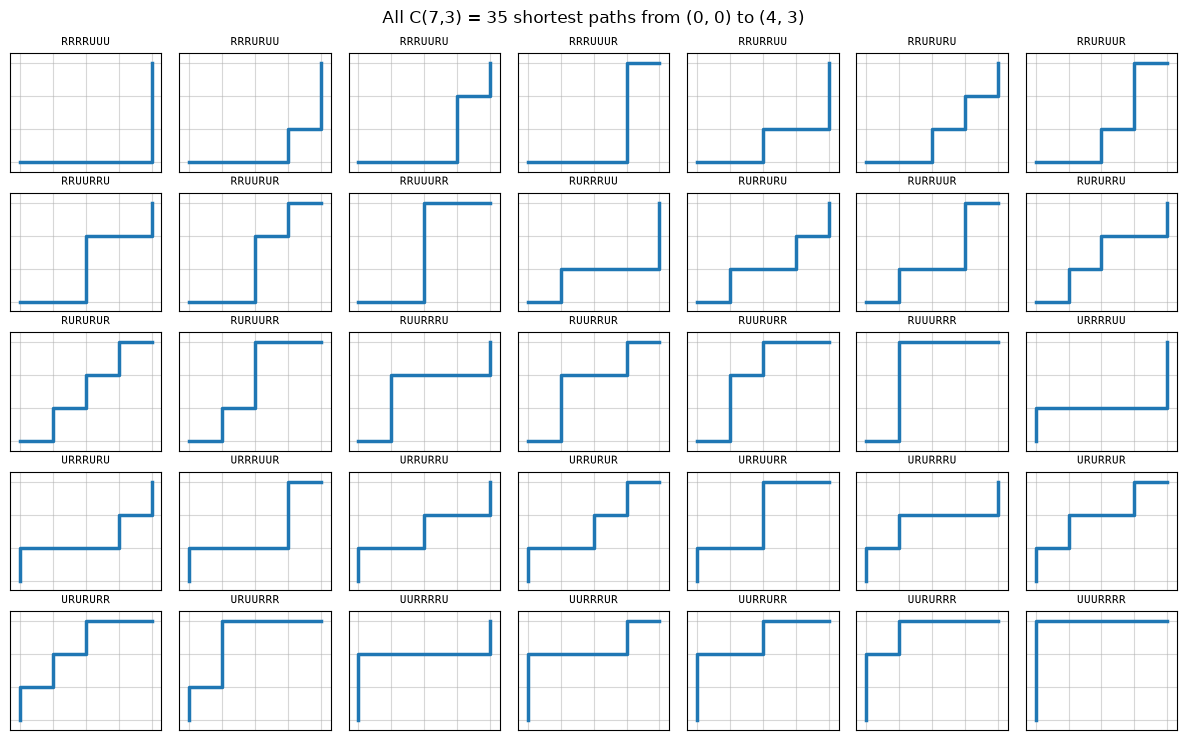

In [13]:
paths = set(permutations("RRRRUUU"))
print("Lattice paths (0,0) → (4,3):", len(paths), "| formula", comb(7, 3))
print("Chessboard rectangles:", comb(9, 2)**2, "| squares:", sum(k*k for k in range(1, 9)))
print("Decagon diagonals:", comb(10, 2) - 10, "| diagonal crossings:", comb(10, 4))

fig, axes = plt.subplots(5, 7, figsize=(12, 7.5))
for ax, path in zip(axes.flat, sorted(paths)):
    pts = [(0, 0)]
    for step in path:
        x0, y0 = pts[-1]
        pts.append((x0 + (step == "R"), y0 + (step == "U")))
    ax.plot(*zip(*pts), color="C0", lw=2.5)
    ax.set_xlim(-0.3, 4.3); ax.set_ylim(-0.3, 3.3); ax.set_xticks(range(5)); ax.set_yticks(range(4))
    ax.tick_params(labelbottom=False, labelleft=False, length=0); ax.grid(True, alpha=0.5); ax.set_aspect("equal")
    ax.set_title("".join(path), fontsize=8, family="monospace")
fig.suptitle("All C(7,3) = 35 shortest paths from (0, 0) to (4, 3)")
plt.tight_layout(); plt.show()

## 13. Inclusion–Exclusion and Derangements

### Inclusion–exclusion principle
$$|A \cup B| = |A| + |B| - |A \cap B|$$
$$|A \cup B \cup C| = |A| + |B| + |C| - |A \cap B| - |B \cap C| - |C \cap A| + |A \cap B \cap C|$$
Add singles, subtract pairs, add triples, …

**Example.** Numbers from 1 to 100 divisible by 2 or 3: $50 + 33 - 16 = 67$.

**Example.** Numbers from 1 to 100 divisible by **none** of 2, 3, 5:
$100 - (50 + 33 + 20) + (16 + 10 + 6) - 3 = 26$.

### Onto (surjective) functions
Distribute $n$ distinct objects into $r$ distinct boxes with **no empty box**:
$$r^n - \binom{r}{1}(r - 1)^n + \binom{r}{2}(r - 2)^n - \dots$$
5 objects into 3 boxes: $3^5 - 3 \cdot 2^5 + 3 \cdot 1^5 = 150$.

### Derangements
A **derangement** is an arrangement where **nothing is in its original place** (e.g. letters all in the wrong envelopes).
$$\boxed{D_n = n!\left(1 - \frac{1}{1!} + \frac{1}{2!} - \frac{1}{3!} + \dots + \frac{(-1)^n}{n!}\right)}$$
Recurrence: $D_n = (n - 1)(D_{n-1} + D_{n-2})$, with $D_1 = 0$, $D_2 = 1$.

| $n$ | 1 | 2 | 3 | 4 | 5 | 6 |
|-----|---|---|---|---|---|---|
| $D_n$ | 0 | 1 | 2 | 9 | 44 | 265 |

- Probability that a random arrangement is a derangement $\to \dfrac{1}{e} \approx 0.368$.
- **Exactly $k$ in the right place:** $\binom{n}{k}D_{n-k}$. For 5 letters, exactly 2 correct: $\binom{5}{2}D_3 = 20$.

Divisible by 2 or 3: 67
Divisible by none of 2, 3, 5: 26
Onto maps 5 → 3: 150 | formula 150
Derangements (formula): [0, 1, 2, 9, 44, 265, 1854]
Derangements (brute)  : [0, 1, 2, 9, 44, 265, 1854]
Exactly 2 of 5 correct: 20 | formula 20


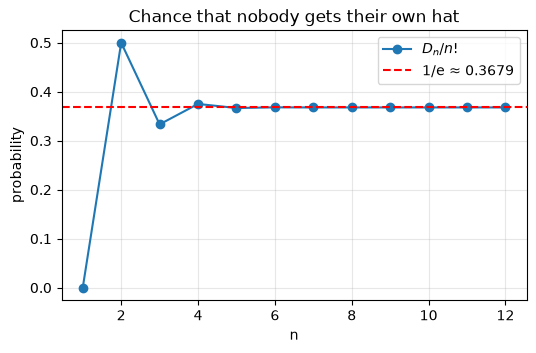

In [14]:
nums = range(1, 101)
print("Divisible by 2 or 3:", sum(1 for k in nums if k % 2 == 0 or k % 3 == 0))
print("Divisible by none of 2, 3, 5:", sum(1 for k in nums if k % 2 and k % 3 and k % 5))
print("Onto maps 5 → 3:", sum(1 for f in product(range(3), repeat=5) if len(set(f)) == 3), "| formula", 3**5 - 3*2**5 + 3)

def D(n):
    return round(factorial(n) * sum((-1)**k / factorial(k) for k in range(n + 1)))
brute = [sum(1 for p in permutations(range(n)) if all(p[i] != i for i in range(n))) for n in range(1, 8)]
print("Derangements (formula):", [D(n) for n in range(1, 8)])
print("Derangements (brute)  :", brute)
print("Exactly 2 of 5 correct:", sum(1 for p in permutations(range(5)) if sum(p[i] == i for i in range(5)) == 2), "| formula", comb(5, 2) * D(3))

ns = np.arange(1, 13)
plt.figure(figsize=(6, 3.5))
plt.plot(ns, [D(int(k)) / factorial(int(k)) for k in ns], "o-", label="$D_n / n!$")
plt.axhline(1 / math.e, color="red", ls="--", label="1/e ≈ 0.3679")
plt.xlabel("n"); plt.ylabel("probability"); plt.grid(alpha=0.3); plt.legend()
plt.title("Chance that nobody gets their own hat")
plt.show()

## 14. Pigeonhole Principle

**Basic form.** If $n + 1$ (or more) objects go into $n$ boxes, some box has **at least two** objects.

**General form.** If $N$ objects go into $k$ boxes, some box has at least $\left\lceil \dfrac{N}{k} \right\rceil$ objects.

To **guarantee** $m$ objects in some box you need $k(m - 1) + 1$ objects (the worst case puts $m - 1$ in every box first).

**Examples**
- Among 13 people, two share a birth month (12 boxes).
- Among 367 people, two share a birthday.
- To guarantee 3 people with the same birth month: $12 \times 2 + 1 = 25$ people.
- Among any 5 integers, two have the same remainder when divided by 4 (only 4 possible remainders).
- A drawer has 10 black and 10 white socks: you must take **3** (in the dark) to be sure of a matching pair.

The principle proves something **exists** without saying which box it is.

## 15. Rank of a Word in the Dictionary

To find the position of a word among all arrangements of its letters listed alphabetically:
1. Write the letters in alphabetical order.
2. For each position from left to right, count the **unused letters that are smaller** than the actual letter; each gives (remaining letters)! words that come earlier.
3. Add everything, then add 1 for the word itself.

**Example.** Rank of MOTHER (letters in order: E, H, M, O, R, T).

| Position | Letter | Smaller unused letters | Words before |
|----------|--------|------------------------|--------------|
| 1 | M | E, H (2) | $2 \times 5! = 240$ |
| 2 | O | E, H (2) | $2 \times 4! = 48$ |
| 3 | T | E, H, R (3) | $3 \times 3! = 18$ |
| 4 | H | E (1) | $1 \times 2! = 2$ |
| 5 | E | — | 0 |
| 6 | R | — | 0 |

Rank $= 240 + 48 + 18 + 2 + 1 = \mathbf{309}$.

(With repeated letters, divide each count by the factorials of the remaining repeats.)

In [15]:
def rank(word):
    letters = sorted(word)
    r = 0
    for ch in word:
        for smaller in sorted(set(l for l in letters if l < ch)):
            rest = letters.copy(); rest.remove(smaller)
            r += multiset_perms(rest)
        letters.remove(ch)
    return r + 1

print("Rank of MOTHER:", rank("MOTHER"), "| brute force:", sorted(set("".join(p) for p in permutations("MOTHER"))).index("MOTHER") + 1)
print("Rank of SCHOOL:", rank("SCHOOL"), "| brute force:", sorted(set("".join(p) for p in permutations("SCHOOL"))).index("SCHOOL") + 1)

Rank of MOTHER: 309 | brute force: 309
Rank of SCHOOL: 303 | brute force: 303


## 16. Common Mistakes

| Mistake | Correct idea |
|---------|-------------|
| Using permutations for a team/committee | Order doesn't matter → combinations |
| Using combinations for rankings, passwords, seating | Order matters → permutations |
| Forgetting the leading-zero restriction for numbers | First digit $\neq 0$ — fill that slot first |
| Not dividing by repeats for identical letters | $\dfrac{n!}{p!\,q!\cdots}$ |
| "Not all together" treated as "no two together" | Different: complement vs. gap method |
| Using $n!$ for a round table | $(n - 1)!$ (and $\tfrac{(n - 1)!}{2}$ for necklaces) |
| "Pick one woman, then choose the rest" for "at least one" | Overcounts — use cases or the complement |
| Forgetting to arrange inside a block | Multiply by the block's internal arrangements |
| Dividing into equal groups without dividing by $k!$ | Unlabelled equal groups → divide by $k!$ |
| Confusing identical vs. distinct objects in distributions | Identical → stars and bars; distinct → $r^n$ |
| Adding when you should multiply (or vice versa) | "and" (stages) → multiply; "or" (cases) → add |
| Counting the same thing twice in "or" cases | Make cases mutually exclusive, or use inclusion–exclusion |

## 17. Formula Sheet

| Situation | Count |
|-----------|-------|
| Multiplication / addition principle | $m \times n$ / $m + n$ |
| Arrange $n$ distinct objects | $n!$ |
| Arrange $r$ of $n$ distinct | ${}^nP_r = \dfrac{n!}{(n - r)!}$ |
| Repetition allowed | $n^r$ |
| Identical objects | $\dfrac{n!}{p!\,q!\,r!\cdots}$ |
| Circular | $(n - 1)!$; necklace $\dfrac{(n - 1)!}{2}$ |
| Select $r$ of $n$ | ${}^nC_r = \dfrac{n!}{r!(n - r)!}$; $\;{}^nP_r = r!\,{}^nC_r$ |
| $k$ included / excluded | $\binom{n - k}{r - k}$ / $\binom{n - k}{r}$ |
| All subsets | $2^n$ |
| Selections from identical groups | $(p + 1)(q + 1)(r + 1) - 1$ |
| Number of divisors of $p^aq^br^c$ | $(a + 1)(b + 1)(c + 1)$ |
| Non-negative solutions of $x_1 + \dots + x_r = n$ | $\binom{n + r - 1}{r - 1}$ |
| Positive solutions | $\binom{n - 1}{r - 1}$ |
| Distinct objects into distinct boxes | $r^n$ |
| Onto functions $n \to r$ | $\sum_{k=0}^{r}(-1)^k\binom{r}{k}(r - k)^n$ |
| Groups of sizes $m, n, p$ | $\dfrac{(m + n + p)!}{m!\,n!\,p!}$ (÷ $k!$ for $k$ equal unlabelled groups) |
| Lines / triangles from $n$ points | $\binom{n}{2}$ / $\binom{n}{3}$ (adjust for collinear) |
| Diagonals of $n$-gon | $\dfrac{n(n - 3)}{2}$ |
| Lattice paths to $(m, n)$ | $\binom{m + n}{m}$ |
| Derangements | $D_n = n!\sum_{k=0}^{n}\dfrac{(-1)^k}{k!}$ |
| Inclusion–exclusion (2 sets) | $\lvert A \cup B\rvert = \lvert A\rvert + \lvert B\rvert - \lvert A \cap B\rvert$ |
| Pigeonhole | some box has $\ge \lceil N/k\rceil$ |
| Trailing zeros of $n!$ | $\lfloor n/5\rfloor + \lfloor n/25\rfloor + \dots$ |

## 18. Practice Problems (with Answers)

### Level 1 — Basics
1. There are 5 roads from A to B and 4 from B to C. In how many ways can one go from A to C via B? In how many ways can one go A → C → A without using any road twice?
2. Evaluate ${}^7P_3$ and ${}^9C_4$.
3. How many 4-letter arrangements (meaningful or not) can be made from the letters of NUMBER without repetition?
4. In how many ways can the letters of ALLAHABAD be arranged?
5. How many 5-digit numbers can be formed from $0, 1, 2, 3, 4$ without repetition? How many of them are divisible by 5?
6. In how many ways can 7 people sit around a round table?

### Level 2 — Standard
7. A committee of 4 is chosen from 6 men and 5 women. How many committees have exactly 2 women?
8. In the same setting, how many committees have at least 2 women?
9. In how many ways can 5 boys and 4 girls stand in a row so that no two girls are together?
10. In how many arrangements of DAUGHTER are the vowels together?
11. 12 points lie in a plane, 5 of them collinear (no other three collinear). How many lines and how many triangles do they determine?
12. How many diagonals does a 12-sided polygon have? Which polygon has 44 diagonals?
13. Find the number of non-negative integer solutions of $x + y + z + w = 12$.
14. In how many ways can 8 identical chocolates be shared among 3 children so that each gets at least one?

### Level 3 — Challenge
15. How many divisors does 720 have? How many of them are even?
16. In how many ways can 5 letters be put into their 5 addressed envelopes so that **no** letter is in the correct envelope?
17. How many integers from 1 to 1000 are divisible by none of 2, 3 and 5?
18. Find the rank of the word MOTHER among all its arrangements listed in dictionary order.
19. How many 5-card hands from a standard deck contain exactly 2 aces?
20. What is the minimum number of people needed to be sure that at least 3 share a birth month?

<details>
<summary><strong>Answers</strong> (click to expand)</summary>

1. $5 \times 4 = 20$; $\;5 \times 4 \times 3 \times 4 = 240$
2. $210$ and $126$
3. ${}^6P_4 = 360$
4. A×4, L×2: $\dfrac{9!}{4!\,2!} = 7560$
5. First digit $\neq 0$: $4 \times 4! = 96$; divisible by 5 → last digit 0: $4! = 24$
6. $6! = 720$
7. $\binom{6}{2}\binom{5}{2} = 150$
8. $\binom{11}{4} - \binom{6}{4} - \binom{6}{3}\binom{5}{1} = 330 - 15 - 100 = 215$
9. $5! \times {}^6P_4 = 120 \times 360 = 43{,}200$
10. Vowels A, U, E as one block: $6! \times 3! = 4320$
11. Lines: $\binom{12}{2} - \binom{5}{2} + 1 = 57$; triangles: $\binom{12}{3} - \binom{5}{3} = 210$
12. $\frac{12 \cdot 9}{2} = 54$; $\;\frac{n(n - 3)}{2} = 44 \Rightarrow n = 11$
13. $\binom{15}{3} = 455$
14. $\binom{7}{2} = 21$
15. $720 = 2^4 \cdot 3^2 \cdot 5$: $5 \times 3 \times 2 = 30$ divisors; even: $4 \times 3 \times 2 = 24$
16. $D_5 = 44$
17. $1000 - (500 + 333 + 200) + (166 + 100 + 66) - 33 = 266$
18. $309$
19. $\binom{4}{2}\binom{48}{3} = 6 \times 17296 = 103{,}776$
20. $12 \times 2 + 1 = 25$

</details>

In [16]:
# Check the practice answers (brute force wherever it is quick)
print(" 1.", 5*4, count((a, b, c, d) for a in range(5) for b in range(4) for c in range(4) for d in range(5) if c != b and d != a))
print(" 2.", perm(7, 3), comb(9, 4))
print(" 3.", count(permutations("NUMBER", 4)))
print(" 4.", multiset_perms("ALLAHABAD"))
fives = [p for p in permutations("01234") if p[0] != "0"]
print(" 5.", len(fives), sum(1 for p in fives if p[-1] in "05"))
print(" 6.", factorial(6))
cm = list(combinations(range(11), 4)); women = lambda c: sum(1 for i in c if i >= 6)
print(" 7.", sum(1 for c in cm if women(c) == 2))
print(" 8.", sum(1 for c in cm if women(c) >= 2))
print(" 9.", factorial(5) * perm(6, 4))
d = list(permutations("DAUGHTER")); vow = set("AUE")
print("10.", sum(1 for p in d if max(i for i, ch in enumerate(p) if ch in vow) - min(i for i, ch in enumerate(p) if ch in vow) == 2))
print("11.", comb(12, 2) - comb(5, 2) + 1, comb(12, 3) - comb(5, 3))
print("12.", 12*9//2, next(n for n in range(4, 30) if n*(n - 3)//2 == 44))
print("13.", sum(1 for t in product(range(13), repeat=4) if sum(t) == 12))
print("14.", sum(1 for t in product(range(1, 9), repeat=3) if sum(t) == 8))
dv = [k for k in range(1, 721) if 720 % k == 0]
print("15.", len(dv), sum(1 for k in dv if k % 2 == 0))
print("16.", sum(1 for p in permutations(range(5)) if all(p[i] != i for i in range(5))))
print("17.", sum(1 for k in range(1, 1001) if k % 2 and k % 3 and k % 5))
print("18.", rank("MOTHER"))
print("19.", comb(4, 2) * comb(48, 3))
print("20.", 12 * 2 + 1)

 1. 20 240
 2. 210 126
 3. 360
 4. 7560
 5. 96 24
 6. 720
 7. 150
 8. 215
 9. 43200
10. 4320
11. 57 210
12. 54 11
13. 455
14. 21
15. 30 24
16. 44
17. 266
18. 309
19. 103776
20. 25
